# **Vishing Detection Using Deep Learning**

# **Import All Library**

In [1]:
import itertools
import os
import pickle
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    Flatten,
    GlobalMaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# --- Random Config ---
RANDOM_STATE = 24  # 19 24
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
def _to_1d_labels(y):
    y = np.asarray(y).reshape(-1)
    # If float probs and not already {0,1}
    if y.dtype.kind == "f":
        uniq = set(np.unique(y))
        if not uniq.issubset({0.0, 1.0}):
            y = (y >= 0.5).astype(int)
    return y.astype(int)

def plot_cm_like_example(y_true, y_pred, title, labels=("Non-scam", "Scam")):
    y_true = _to_1d_labels(y_true)
    y_pred = _to_1d_labels(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # 0=Non-scam, 1=Scam

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    plt.colorbar(im, ax=ax)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="black",
                fontsize=12
            )

    fig.tight_layout()
    plt.show()

def confusion_by_type_2x2(y_true, y_pred, test_df_with_type,
                          types=("Support", "Reward", "Refund", "SSN"),
                          model_name="MODEL",
                          labels=("Non-scam", "Scam")):
    y_true = _to_1d_labels(y_true)
    y_pred = _to_1d_labels(y_pred)

    df = test_df_with_type.reset_index(drop=True).copy()
    if "category_4" not in df.columns:
        raise ValueError("test_df_with_type must contain column 'category_4'")

    print("\n" + "=" * 90)
    print(f"{model_name} | Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print("Per-type confusion matrices (plotted)")

    for t in types:
        idx = df["category_4"].astype(str).str.strip().eq(t)
        n = int(idx.sum())

        if n == 0:
            print(f"\n[{t}] -> 0 rows (skipped)")
            continue

        print(f"\n[{t}] (n={n})")
        plot_cm_like_example(
            y_true[idx],
            y_pred[idx],
            title=f"{model_name} - {t} Confusion Matrix (n={n})",
            labels=labels
        )

# **Load Dataset**

In [3]:
# Basic settings
RANDOM_STATE = 42
TEXT_COL = "message"

DATA_PATH = "dataset/real_life_scam_non_scam_dataset.csv"

In [4]:
def clean_text(text):
    text = str(text)
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [5]:
# If your file is inside dataset folder, use this instead:
# DATA_PATH = "dataset/real_life_scam_non_scam_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Cannot find file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label_name"].value_counts())

print("\nSource distribution:")
print(df["source_dataset"].value_counts())

display(df.head())


Dataset loaded successfully!
Shape: (105627, 5)

Columns:
['message', 'label', 'label_name', 'source_dataset', 'data_type']

Label distribution:
label_name
non-scam    57947
scam        47680
Name: count, dtype: int64

Source distribution:
source_dataset
meajor             104572
analysisdataset      1055
Name: count, dtype: int64


,message,label,label_name,source_dataset,data_type
0,"Update Meeting for Monday, [DATE] has been can...",0,non-scam,meajor,email
1,[ORGANIZATION] [ADDRESS] and [ORGANIZATION] re...,1,scam,meajor,email
2,DSJ - DOURO S JOAO MUSIC FEST - [DATE] 550 5.1...,1,scam,meajor,email
3,CHASE: Review an attempt to charge $928.65 Rep...,1,scam,analysisdataset,sms
4,"Yo! Hey ! ""During a daytime I usually take cla...",1,scam,meajor,email


# Data Cleaning

In [6]:
import re
import html

def clean_message(text):
    text = str(text).lower()
    text = html.unescape(text)

    # Remove old synthetic leakage if it exists
    text = re.sub(
        r"\breference\s*:\s*\[(case|ref)_\d+\]\s*\.?",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Remove letter id leakage
    text = re.sub(
        r"\[letter id:\s*\[reference_number\]\]",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Convert real URLs into normal token
    text = re.sub(
        r"http\S+|www\.\S+",
        " url ",
        text,
        flags=re.IGNORECASE
    )

    # Convert email addresses into normal token
    text = re.sub(
        r"\b[\w\.-]+@[\w\.-]+\.\w+\b",
        " email ",
        text,
        flags=re.IGNORECASE
    )

    # Convert phone-like numbers into normal token
    text = re.sub(
        r"\b(?:\+?\d[\d\s\-()]{6,}\d)\b",
        " phone ",
        text
    )

    # Handle <|URL|>, <|EMAIL|>, <|PHONE|>, <|FILE|>, etc.
    def replace_angle_token(match):
        token = match.group(1).lower()
        token = token.replace("simbol", "symbol")

        if "url" in token:
            return " url "
        elif "email" in token:
            return " email "
        elif "phone" in token:
            return " phone "
        elif "file" in token:
            return " file "
        elif "emoji" in token or "symbol" in token:
            return " "
        else:
            token = re.sub(r"[^a-z0-9]+", " ", token)
            return " " + token + " "

    text = re.sub(
        r"<\|([^|]+)\|>",
        replace_angle_token,
        text,
        flags=re.IGNORECASE
    )

    # Handle [REFERENCE_NUMBER], [NAME], [DATE], [[PRODUCT]], etc.
    def replace_square_token(match):
        token = match.group(1).lower()
        token = token.replace("_", " ")

        if token in ["fake link", "url"]:
            return " url "
        elif token in ["phone number", "phone"]:
            return " phone "
        elif token in ["email address", "email"]:
            return " email "
        elif token in ["reference number"]:
            return " number "
        elif token in ["date", "time", "location", "address"]:
            return " " + token + " "
        elif token in ["name", "organization", "product", "username"]:
            return " " + token + " "
        elif token in ["file name", "file path"]:
            return " file "
        else:
            return " " + token + " "

    text = re.sub(
        r"\[+\s*([a-zA-Z_ ]+)\s*\]+",
        replace_square_token,
        text,
        flags=re.IGNORECASE
    )

    # Remove wiki-style metadata noise like ///color/// or ///population_density///
    text = re.sub(
        r"///[a-zA-Z_]+///?",
        " ",
        text
    )

    # Normalize urgency time
    # Example: 24 hours, 48 hrs, 72 h -> time limit
    text = re.sub(
        r"\b(6|12|24|48|72)\s*(hours?|hrs?|h)\b",
        " time limit ",
        text,
        flags=re.IGNORECASE
    )

    # Normalize very long numbers only
    # Keeps useful short numbers like 365, but replaces random IDs
    text = re.sub(
        r"\b\d{4,}\b",
        " number ",
        text
    )

    # Remove punctuation/symbols but keep letters and numbers
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply cleaning to the full dataset
df["clean_message"] = df["message"].apply(clean_message)
print("clean_message column created.")
print(f"Total rows: {len(df):,}")


clean_message column created.
Total rows: 105,627


## Cleaned message before and after

In [7]:


# Show full column content
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

comparison_table = (
    df[["message", "clean_message"]]
    .head(5)
    .reset_index(drop=True)
)

comparison_table.index = comparison_table.index + 1

comparison_table = comparison_table.rename(columns={
    "message": "Original Message",
    "clean_message": "Cleaned Message"
})

display(comparison_table)

,Original Message,Cleaned Message
1,"Update Meeting for Monday, [DATE] has been cancelled. We will meet tomorrow morning in 16C1 at [TIME] If you have any questions, please contact me at [PHONE_NUMBER]. See you in the morning! [NAME]",update meeting for monday date has been cancelled we will meet tomorrow morning in 16c1 at time if you have any questions please contact me at phone see you in the morning name
2,"[ORGANIZATION] [ADDRESS] and [ORGANIZATION] renew their agreement. This week, we're telling you how to lower your [PRODUCT] costs while increasing your profit. Search engine news of the week [ORGANIZATION] releases [PRODUCT] search engine [ORGANIZATION] has just released a special search form for its AdWords ads. [ORGANIZATION] set to buy desktop search firm ""[ORGANIZATION]. Many people use [ORGANIZATION] to find web sites on the Internet. It was from a person who received the following answer to a PageRank question from a [ORGANIZATION] employee: ""The PageRank that is displayed in the [PRODUCT] is for entertainment purposes only. "" The magic that makes [ORGANIZATION] tick ""[ORGANIZATION] vice-president of engineering was in London this week to talk to potential recruits about just what lies behind that search page. How to fake [ORGANIZATION] PageRank numbers View all past issues. Just use [ORGANIZATION]mon sense. "" 2005: The Year for Desktop Search ""What [ORGANIZATION] knows that even the top of the heap of Web search engines do not is how to control loyalty on the desktop. For example, [PRODUCT] uses data about the overall popularity of various searches to help rank the refinements it offers. How does [ORGANIZATION] rank web pages? [ORGANIZATION] publishes a list of the most linked pages on the web. Announcement: How to optimize your [PRODUCT] campaigns [ORGANIZATION] AdWords are small text ads that appear next to the search results on [ORGANIZATION]. Make sure that your web pages are optimized for [ORGANIZATION]. Some CEOs surf Web to see how they're being portrayed. "" 2005: The Year for Desktop Search ""What [ORGANIZATION] knows that even the top of the heap of Web search engines do not is how to control loyalty on the desktop. is trying to establish an online reading room for five major libraries by scanning stacks of hard-to-find books into its widely used Internet search engine. Back to table of contents - Visit Axandra. Could visitors of the other web site be interested in your site? Further information about [ORGANIZATION] library project. "" [ORGANIZATION] launching second act with e-mail client ""With the launch of the [PRODUCT]. If you like a page, changes are that other people also like that page, no matter what PageRank the [ORGANIZATION] toolbar displays. Take a look at the top searches on [ORGANIZATION] in 2004. Lower your advertising costs and make more profit! He said that toolbar users use the PageRank display to judge the quality of web pages. Last week, two statements about [ORGANIZATION] PageRank started a new discussion about this topic. Though the 500 so-called second-tier search engines garner as little as 2 percent of the search market share, they offer something [ORGANIZATION] and [ORGANIZATION] increasingly do not: low-priced leads. Back to table of contents - Visit Axandra. Some people talk about their job interviews at [ORGANIZATION]. Articles of the week Accoona: Should [ORGANIZATION] worry? This 150-page eBook tells you how to find affordable keywords, how to write successful ads and how to increase the effectiveness of your AdWords ads. Just enter a keyword or phrase, and [PRODUCT] will quickly retrieve any file or email on your hard drive matching your query. ] Here is a roundup of some of the questions asked and answers posited. What are their navigation habits? "" Search engine newslets U. [ADDRESS] has enhanced its range of financial services ""The Internet portal [ORGANIZATION] However, the PageRank number that is displayed in the [PRODUCT] and the green PageRank bar are not 

In [30]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────
# RANDOM CONFIG
# ─────────────────────────────────────────────

RANDOM_STATE = 24

# ─────────────────────────────────────────────
# PREPARE LABELS
# ─────────────────────────────────────────────

df.columns = [c.strip().lower() for c in df.columns]

label_text = df["label"].astype(str).str.lower().str.strip()
label_map = {
    "scam": 1,
    "1": 1,
    "non-scam": 0,
    "nonscam": 0,
    "non scam": 0,
    "0": 0
}
df["label"] = label_text.map(label_map)

if df["label"].isna().any():
    print("Unknown labels found:")
    print(label_text[df["label"].isna()].unique())
    raise ValueError("Some labels could not be converted.")

df["label"] = df["label"].astype(int)

TEXT_COL = "clean_message" if "clean_message" in df.columns else "message"
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != ""].reset_index(drop=True)

print("Using text column:", TEXT_COL)
print("Dataset shape:", df.shape)
print(df["label"].value_counts().rename({1: "scam", 0: "non-scam"}))


# ─────────────────────────────────────────────
# SHUFFLE FUNCTION
# ─────────────────────────────────────────────

def shuffle_split_data(data, random_state=24):
    scam_part    = data[data["label"] == 1].sample(frac=1, random_state=random_state)
    nonscam_part = data[data["label"] == 0].sample(frac=1, random_state=random_state)
    return (
        pd.concat([scam_part, nonscam_part], ignore_index=True)
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )


# ─────────────────────────────────────────────
# SPLIT 80 / 10 / 10
# ─────────────────────────────────────────────

train_data, temp_data = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=RANDOM_STATE,
    shuffle=True
)

valid_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["label"],
    random_state=RANDOM_STATE,
    shuffle=True
)

train_data = shuffle_split_data(train_data, RANDOM_STATE)
valid_data = shuffle_split_data(valid_data, RANDOM_STATE)
test_data  = shuffle_split_data(test_data,  RANDOM_STATE)

X_train, y_train = train_data[TEXT_COL], train_data["label"]
X_valid, y_valid = valid_data[TEXT_COL], valid_data["label"]
X_test,  y_test  = test_data[TEXT_COL],  test_data["label"]


# ─────────────────────────────────────────────
# SPLIT 70 / 15 / 15
# ─────────────────────────────────────────────

train_data_70, temp_data_30 = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=RANDOM_STATE,
    shuffle=True
)

valid_data_15, test_data_15 = train_test_split(
    temp_data_30,
    test_size=0.50,
    stratify=temp_data_30["label"],
    random_state=RANDOM_STATE,
    shuffle=True
)

train_data_70 = shuffle_split_data(train_data_70, RANDOM_STATE)
valid_data_15 = shuffle_split_data(valid_data_15, RANDOM_STATE)
test_data_15  = shuffle_split_data(test_data_15,  RANDOM_STATE)

X_train_70, y_train_70 = train_data_70[TEXT_COL], train_data_70["label"]
X_valid_15, y_valid_15 = valid_data_15[TEXT_COL], valid_data_15["label"]
X_test_15,  y_test_15  = test_data_15[TEXT_COL],  test_data_15["label"]


# ─────────────────────────────────────────────
# PRINT SPLIT DISTRIBUTION
# ─────────────────────────────────────────────

def print_split(name, data):
    scam_count    = (data["label"] == 1).sum()
    nonscam_count = (data["label"] == 0).sum()
    print(f"{name}: {len(data):,}  (scam={scam_count:,}, non-scam={nonscam_count:,})")

print("\n80 / 10 / 10 Split Distribution")
print("================================")
print_split("Train", train_data)
print_split("Valid", valid_data)
print_split("Test ", test_data)

print("\n70 / 15 / 15 Split Distribution")
print("================================")
print_split("Train 70%", train_data_70)
print_split("Valid 15%", valid_data_15)
print_split("Test  15%", test_data_15)


Using text column: clean_message
Dataset shape: (105601, 6)
label
non-scam    57947
scam        47654
Name: count, dtype: int64

80 / 10 / 10 Split Distribution
Train: 84,480  (scam=38,123, non-scam=46,357)
Valid: 10,560  (scam=4,765, non-scam=5,795)
Test : 10,561  (scam=4,766, non-scam=5,795)

70 / 15 / 15 Split Distribution
Train 70%: 73,920  (scam=33,357, non-scam=40,563)
Valid 15%: 15,840  (scam=7,148, non-scam=8,692)
Test  15%: 15,841  (scam=7,149, non-scam=8,692)


# Dataset Split Variables

## 80 / 10 / 10 Split

| Dataset Part | Features Variable | Label Variable | Purpose |
|---|---|---|---|
| Training Set | `X_train` | `y_train` | Used to train the model |
| Validation Set | `X_valid` | `y_valid` | Not used |
| Test Set | `X_test` | `y_test` | Used for final evaluation |

---

## 70 / 15 / 15 Split

| Dataset Part | Features Variable | Label Variable | Purpose |
|---|---|---|---|
| Training Set | `X_train_70` | `y_train_70` | Used to train the model |
| Validation Set | `X_valid_15` | `y_valid_15` | Not used |
| Test Set | `X_test_15` | `y_test_15` | Used for final evaluation |

---

## Split Comparison

| Split Ratio | Training | Validation | Testing |
|---|---:|---:|---:|
| 80 / 10 / 10 | 80% | 10% | 10% |
| 70 / 15 / 15 | 70% | 15% | 15% |

**Note:**  
The 80/10/10 split gives more data for training.  
The 70/15/15 split gives more data for validation and testing.

# **Tokenization**

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# TOKENIZATION
# Fit on 80/10/10 training data only; reuse tokenizer for 70/15/15 split.
# ═══════════════════════════════════════════════════════════════════════════════

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE   = 30000   # covers full dataset vocabulary
MAX_LENGTH   = 100     # most messages are < 50 tokens after cleaning
OOV_TOKEN    = "<OOV>"
PADDING_TYPE = "post"
TRUNC_TYPE   = "post"

# Fit tokenizer on 80/10/10 training split only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_data[TEXT_COL].astype(str))

# ── 80/10/10 sequences ────────────────────────────────────────────────────
X_train_seq = tokenizer.texts_to_sequences(train_data[TEXT_COL].astype(str))
X_valid_seq = tokenizer.texts_to_sequences(valid_data[TEXT_COL].astype(str))
X_test_seq  = tokenizer.texts_to_sequences(test_data[TEXT_COL].astype(str))

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
X_valid_pad = pad_sequences(X_valid_seq, maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)

y_train_arr = train_data["label"].values
y_valid_arr = valid_data["label"].values
y_test_arr  = test_data["label"].values

# ── 70/15/15 sequences ────────────────────────────────────────────────────
X_train_70_seq = tokenizer.texts_to_sequences(train_data_70[TEXT_COL].astype(str))
X_valid_15_seq = tokenizer.texts_to_sequences(valid_data_15[TEXT_COL].astype(str))
X_test_15_seq  = tokenizer.texts_to_sequences(test_data_15[TEXT_COL].astype(str))

X_train_70_pad = pad_sequences(X_train_70_seq, maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
X_valid_15_pad = pad_sequences(X_valid_15_seq, maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
X_test_15_pad  = pad_sequences(X_test_15_seq,  maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)

y_train_70_arr = train_data_70["label"].values
y_valid_15_arr = valid_data_15["label"].values
y_test_15_arr  = test_data_15["label"].values

print("80/10/10 shapes:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_valid_pad : {X_valid_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")

print("\n70/15/15 shapes:")
print(f"  X_train_70_pad : {X_train_70_pad.shape}")
print(f"  X_valid_15_pad : {X_valid_15_pad.shape}")
print(f"  X_test_15_pad  : {X_test_15_pad.shape}")

pct_trunc = sum(len(s) > MAX_LENGTH for s in X_train_seq) / len(X_train_seq) * 100
print(f"\nTrain sequences truncated (>{MAX_LENGTH} tokens): {pct_trunc:.1f}%")


80/10/10 shapes:
  X_train_pad : (84480, 100)
  X_valid_pad : (10560, 100)
  X_test_pad  : (10561, 100)

70/15/15 shapes:
  X_train_70_pad : (73920, 100)
  X_valid_15_pad : (15840, 100)
  X_test_15_pad  : (15841, 100)

Train sequences truncated (>100 tokens): 60.2%


# **Random Search**

Random Search Config
CNN iterations : 8
MLP iterations : 8
Folds          : 3
Output folder  : results_dl

Random Search Size
CNN configs : 8
MLP configs : 8
Splits      : 2
Folds       : 3
Total CV fold runs: 96

Resume check
Completed configs found: 4
Total random-search jobs: 32
Random Search |███░░░░░░░░░░░░░░░░░░░░░░░░░░░| 4/32 (12.5%) CV Macro F1=0.0000 ETA=0.0min

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Random Search |████░░░░░░░░░░░░░░░░░░░░░░░░░░| 5/32 (15.6%) CV Macro F1=0.9728 ETA=35.0min

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Random Search |█████░░░░░░░░░░░░░░░░░░░░░░░░░| 6/32 (18.8%) CV Macro F1=0.9711 ETA=57.2min

...

Random Search |██████████████████████████████| 32/32 (100.0%) CV Macro F1=0.9670 ETA=0.0min

Random search completed.
Results saved to     : results_dl\dl_results_live.csv
Fold results saved to: results_dl\dl_fold_results_live.csv
Best summary saved to: results_dl\dl_best_summary_live.csv


════════════════════════════════════════════════════════════════════════════════
BEST RANDOM SEARCH CONFIGURATION PER SPLIT × MODEL
Ranked by CV Macro F1
════════════════════════════════════════════════════════════════════════════════


,split,model,config_id,embedding_dim,filters,kernel_size,dense_units,dropout_rate,learning_rate,batch_size,cv_f1_macro_mean,cv_f1_macro_std,cv_scam_recall_mean,test_accuracy,test_f1_macro,test_scam_recall
0,80/10/10,CNN,1,128,32.000000,5.000000,128,0.300000,0.000500,32,0.9747,0.0008,0.9718,0.9739,0.9736,0.9694
1,80/10/10,MLP,6,128,nan,nan,64,0.300000,0.001000,32,0.9747,0.0009,0.9716,0.9767,0.9765,0.9708
2,70/15/15,CNN,1,128,32.000000,5.000000,128,0.300000,0.000500,32,0.9742,0.0010,0.9706,0.9749,0.9747,0.9722
3,70/15/15,MLP,2,128,nan,nan,64,0.500000,0.000500,32,0.9738,0.0017,0.9698,0.9770,0.9768,0.9835



🏆 Overall Best Random Search Configuration
Split      : 80/10/10
Model      : CNN
Config ID  : 1
CV Macro F1: 0.9747
Test Macro F1: 0.9736
Test Scam Recall: 0.9694


════════════════════════════════════════════════════════════════════════════════
DETAILED CLASSIFICATION REPORTS FOR BEST RANDOM SEARCH CONFIGS
════════════════════════════════════════════════════════════════════════════════


C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



── 80/10/10 | CNN | Config 1 ──
              precision    recall  f1-score   support

    Non-Scam     0.9746    0.9788    0.9767      5795
        Scam     0.9741    0.9689    0.9715      4766

    accuracy                         0.9743     10561
   macro avg     0.9743    0.9739    0.9741     10561
weighted avg     0.9743    0.9743    0.9743     10561



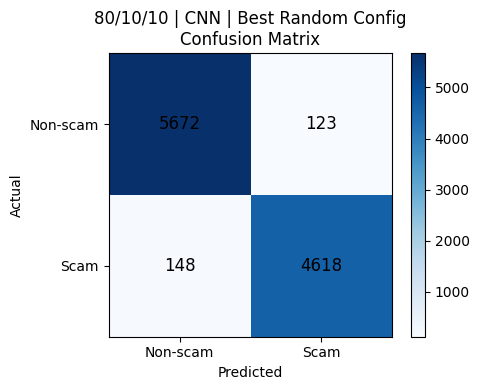

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



── 80/10/10 | MLP | Config 6 ──
              precision    recall  f1-score   support

    Non-Scam     0.9785    0.9757    0.9771      5795
        Scam     0.9705    0.9740    0.9722      4766

    accuracy                         0.9749     10561
   macro avg     0.9745    0.9748    0.9747     10561
weighted avg     0.9749    0.9749    0.9749     10561



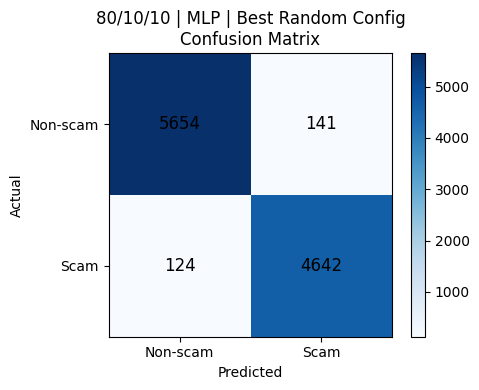

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



── 70/15/15 | CNN | Config 1 ──
              precision    recall  f1-score   support

    Non-Scam     0.9837    0.9726    0.9781      8692
        Scam     0.9672    0.9804    0.9737      7149

    accuracy                         0.9761     15841
   macro avg     0.9754    0.9765    0.9759     15841
weighted avg     0.9762    0.9761    0.9762     15841



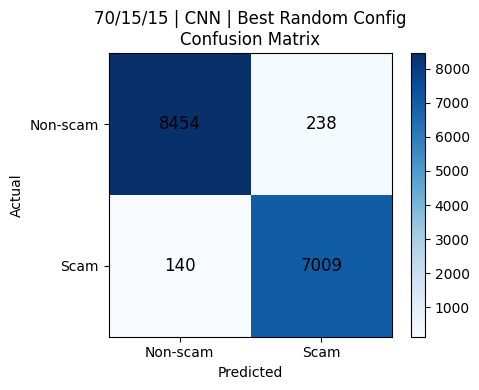

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



── 70/15/15 | MLP | Config 2 ──
              precision    recall  f1-score   support

    Non-Scam     0.9810    0.9763    0.9787      8692
        Scam     0.9714    0.9771    0.9742      7149

    accuracy                         0.9766     15841
   macro avg     0.9762    0.9767    0.9764     15841
weighted avg     0.9767    0.9766    0.9766     15841



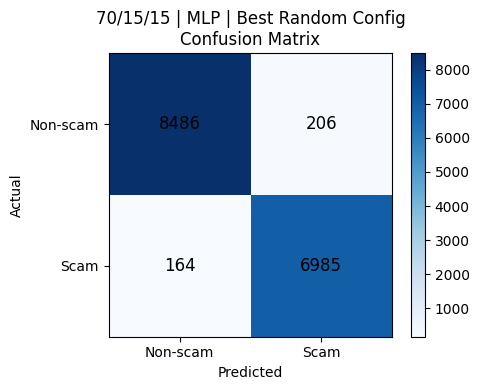

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# RANDOM SEARCH + 3-FOLD CV + AUTO-SAVE CHECKPOINTS
#
# Models:  CNN  |  MLP
# Splits:  80/10/10  |  70/15/15
#
# Saves:
#   results_dl/dl_fold_results_live.csv
#   results_dl/dl_results_live.csv
#   results_dl/dl_best_summary_live.csv
#   results_dl/dl_errors.csv
# ═══════════════════════════════════════════════════════════════════════════════

import os
import time
import json
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

RANDOM_STATE = 24
N_FOLDS      = 3
N_ITER_CNN   = 8
N_ITER_MLP   = 8

OUTPUT_DIR        = "results_dl"
RESULTS_PATH      = os.path.join(OUTPUT_DIR, "dl_results_live.csv")
FOLD_RESULTS_PATH = os.path.join(OUTPUT_DIR, "dl_fold_results_live.csv")
BEST_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "dl_best_summary_live.csv")
ERROR_LOG_PATH    = os.path.join(OUTPUT_DIR, "dl_errors.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Random Search Config")
print("====================")
print("CNN iterations :", N_ITER_CNN)
print("MLP iterations :", N_ITER_MLP)
print("Folds          :", N_FOLDS)
print("Output folder  :", OUTPUT_DIR)


# ═══════════════════════════════════════════════════════════════════════════════
# SPLITS  (padded sequences + labels, keyed by split name)
# ═══════════════════════════════════════════════════════════════════════════════

SPLITS = {
    "80/10/10": {
        "X_train": X_train_pad,
        "y_train": y_train_arr,
        "X_test" : X_test_pad,
        "y_test" : y_test_arr,
        "X_valid": X_valid_pad,
        "y_valid": y_valid_arr,
    },
    "70/15/15": {
        "X_train": X_train_70_pad,
        "y_train": y_train_70_arr,
        "X_test" : X_test_15_pad,
        "y_test" : y_test_15_arr,
        "X_valid": X_valid_15_pad,
        "y_valid": y_valid_15_arr,
    },
}


# ═══════════════════════════════════════════════════════════════════════════════
# PARAMETER DISTRIBUTIONS
# ═══════════════════════════════════════════════════════════════════════════════

CNN_PARAM_DIST = {
    "embedding_dim" : [32, 64, 128],
    "filters"       : [32, 64, 128],
    "kernel_size"   : [3, 5],
    "dense_units"   : [64, 128],
    "dropout_rate"  : [0.2, 0.3, 0.5],
    "learning_rate" : [0.001, 0.0005],
    "batch_size"    : [32, 64],
    "num_epochs"    : [10],
}

MLP_PARAM_DIST = {
    "embedding_dim" : [32, 64, 128],
    "dense_units"   : [64, 128, 256],
    "dropout_rate"  : [0.2, 0.3, 0.5],
    "learning_rate" : [0.001, 0.0005],
    "batch_size"    : [32, 64],
    "num_epochs"    : [10],
}

# Sample randomly from distributions
rng = np.random.RandomState(RANDOM_STATE)

def sample_params(dist, n_iter, seed):
    rng_local = np.random.RandomState(seed)
    return [
        {k: rng_local.choice(v) for k, v in dist.items()}
        for _ in range(n_iter)
    ]

CNN_RANDOM_CONFIGS = sample_params(CNN_PARAM_DIST, N_ITER_CNN, RANDOM_STATE)
MLP_RANDOM_CONFIGS = sample_params(MLP_PARAM_DIST, N_ITER_MLP, RANDOM_STATE + 1)

print("\nRandom Search Size")
print("==================")
print("CNN configs :", len(CNN_RANDOM_CONFIGS))
print("MLP configs :", len(MLP_RANDOM_CONFIGS))
print("Splits      :", len(SPLITS))
print("Folds       :", N_FOLDS)
total_runs = (len(CNN_RANDOM_CONFIGS) + len(MLP_RANDOM_CONFIGS)) * len(SPLITS) * N_FOLDS
print("Total CV fold runs:", total_runs)


# ═══════════════════════════════════════════════════════════════════════════════
# MODEL BUILDERS
# ═══════════════════════════════════════════════════════════════════════════════

def build_cnn(params):
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=int(params["embedding_dim"]),
            input_length=MAX_LENGTH
        ),
        Conv1D(
            filters=int(params["filters"]),
            kernel_size=int(params["kernel_size"]),
            activation="relu"
        ),
        GlobalMaxPooling1D(),
        Dense(int(params["dense_units"]), activation="relu"),
        Dropout(float(params["dropout_rate"])),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=float(params["learning_rate"])),
        metrics=["accuracy"],
    )
    return model


def build_mlp(params):
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=int(params["embedding_dim"]),
            input_length=MAX_LENGTH
        ),
        GlobalMaxPooling1D(),
        Dense(int(params["dense_units"]), activation="relu"),
        Dropout(float(params["dropout_rate"])),
        Dense(int(params["dense_units"]) // 2, activation="relu"),
        Dropout(float(params["dropout_rate"])),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=float(params["learning_rate"])),
        metrics=["accuracy"],
    )
    return model


# ═══════════════════════════════════════════════════════════════════════════════
# METRIC HELPER
# ═══════════════════════════════════════════════════════════════════════════════

def compute_metrics(y_true, y_pred):
    return {
        "accuracy"           : accuracy_score(y_true, y_pred),
        "precision_weighted" : precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted"    : recall_score   (y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted"        : f1_score       (y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro"    : precision_score(y_true, y_pred, average="macro",    zero_division=0),
        "recall_macro"       : recall_score   (y_true, y_pred, average="macro",    zero_division=0),
        "f1_macro"           : f1_score       (y_true, y_pred, average="macro",    zero_division=0),
        "scam_recall"        : recall_score   (y_true, y_pred, pos_label=1,        zero_division=0),
        "nonscam_recall"     : recall_score   (y_true, y_pred, pos_label=0,        zero_division=0),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# PIPELINE: build → train → predict
# ═══════════════════════════════════════════════════════════════════════════════

def run_dl_pipeline(X_tr, y_tr, X_te, y_te, params, model_type, X_val=None, y_val=None):
    tf.random.set_seed(RANDOM_STATE)

    if model_type == "CNN":
        model = build_cnn(params)
    else:
        model = build_mlp(params)

    early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

    val_data = (X_val, y_val) if X_val is not None else (X_te, y_te)

    model.fit(
        X_tr, y_tr,
        validation_data=val_data,
        epochs=int(params["num_epochs"]),
        batch_size=int(params["batch_size"]),
        callbacks=[early_stop],
        verbose=0,
    )

    y_probs = model.predict(X_te, verbose=0).ravel()
    y_pred  = (y_probs >= 0.5).astype(int)

    metrics = compute_metrics(y_te, y_pred)
    return {**metrics, "y_pred": y_pred, "model": model}


# ═══════════════════════════════════════════════════════════════════════════════
# SAVE HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def append_row_csv(row, path):
    row_df     = pd.DataFrame([row])
    file_exists = os.path.exists(path)
    row_df.to_csv(path, mode="a", header=not file_exists, index=False)


def load_completed_configs(path):
    if not os.path.exists(path):
        return set()
    old = pd.read_csv(path)
    required = {"split", "model", "config_id"}
    if not required.issubset(old.columns):
        return set()
    return set(zip(old["split"].astype(str), old["model"].astype(str), old["config_id"].astype(int)))


def update_best_summary():
    if not os.path.exists(RESULTS_PATH):
        return
    df_live = pd.read_csv(RESULTS_PATH)
    if len(df_live) == 0:
        return
    summary = (
        df_live
        .sort_values("cv_f1_macro_mean", ascending=False)
        .groupby(["split", "model"], sort=False)
        .first()
        .reset_index()
        .sort_values("cv_f1_macro_mean", ascending=False)
        .reset_index(drop=True)
    )
    summary.to_csv(BEST_SUMMARY_PATH, index=False)


# ═══════════════════════════════════════════════════════════════════════════════
# CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════════

def cross_validate_dl(X_all, y_all, params, model_type, split_name, model_name, config_id):
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_rows = []

    for fold_no, (tr_idx, val_idx) in enumerate(cv.split(X_all, y_all), 1):
        t0 = time.time()

        result = run_dl_pipeline(
            X_all[tr_idx], y_all[tr_idx],
            X_all[val_idx], y_all[val_idx],
            params, model_type
        )

        elapsed = time.time() - t0

        fold_row = {
            "timestamp"           : time.strftime("%Y-%m-%d %H:%M:%S"),
            "search_type"         : "random_search",
            "split"               : split_name,
            "model"               : model_name,
            "config_id"           : config_id,
            "fold"                : fold_no,
            "accuracy"            : round(result["accuracy"],           4),
            "precision_weighted"  : round(result["precision_weighted"], 4),
            "recall_weighted"     : round(result["recall_weighted"],    4),
            "f1_weighted"         : round(result["f1_weighted"],        4),
            "precision_macro"     : round(result["precision_macro"],    4),
            "recall_macro"        : round(result["recall_macro"],       4),
            "f1_macro"            : round(result["f1_macro"],           4),
            "scam_recall"         : round(result["scam_recall"],        4),
            "nonscam_recall"      : round(result["nonscam_recall"],     4),
            "time_sec"            : round(elapsed, 2),
        }

        append_row_csv(fold_row, FOLD_RESULTS_PATH)
        fold_rows.append(fold_row)

    fold_df = pd.DataFrame(fold_rows)
    return {
        "cv_accuracy_mean"      : fold_df["accuracy"].mean(),
        "cv_accuracy_std"       : fold_df["accuracy"].std(),
        "cv_f1_weighted_mean"   : fold_df["f1_weighted"].mean(),
        "cv_f1_weighted_std"    : fold_df["f1_weighted"].std(),
        "cv_f1_macro_mean"      : fold_df["f1_macro"].mean(),
        "cv_f1_macro_std"       : fold_df["f1_macro"].std(),
        "cv_scam_recall_mean"   : fold_df["scam_recall"].mean(),
        "cv_scam_recall_std"    : fold_df["scam_recall"].std(),
        "cv_nonscam_recall_mean": fold_df["nonscam_recall"].mean(),
        "cv_nonscam_recall_std" : fold_df["nonscam_recall"].std(),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# PROGRESS BAR
# ═══════════════════════════════════════════════════════════════════════════════

def print_progress(tag, i, total, start_time, score):
    pct        = i / total
    bar_filled = int(pct * 30)
    bar        = "█" * bar_filled + "░" * (30 - bar_filled)
    elapsed    = time.time() - start_time
    eta        = (elapsed / i) * (total - i) if i > 0 else 0
    print(
        f"\r{tag} |{bar}| {i}/{total} "
        f"({pct*100:.1f}%) "
        f"CV Macro F1={score:.4f} "
        f"ETA={eta/60:.1f}min",
        end="", flush=True
    )


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN RANDOM SEARCH LOOP
# ═══════════════════════════════════════════════════════════════════════════════

completed_configs = load_completed_configs(RESULTS_PATH)
print("\nResume check")
print("============")
print("Completed configs found:", len(completed_configs))

all_jobs = []
for split_name in SPLITS.keys():
    for config_id, params in enumerate(CNN_RANDOM_CONFIGS, 1):
        all_jobs.append((split_name, "CNN", "CNN", config_id, params))
    for config_id, params in enumerate(MLP_RANDOM_CONFIGS, 1):
        all_jobs.append((split_name, "MLP", "MLP", config_id, params))

print("Total random-search jobs:", len(all_jobs))

overall_start = time.time()
job_counter   = 0

for split_name, model_name, model_type, config_id, params in all_jobs:
    job_counter += 1
    config_key  = (str(split_name), str(model_name), int(config_id))

    if config_key in completed_configs:
        print_progress("Random Search", job_counter, len(all_jobs), overall_start, 0)
        continue

    split_cfg = SPLITS[split_name]
    X_tr      = split_cfg["X_train"]
    y_tr      = split_cfg["y_train"]
    X_te      = split_cfg["X_test"]
    y_te      = split_cfg["y_test"]
    X_val     = split_cfg["X_valid"]
    y_val     = split_cfg["y_valid"]

    try:
        config_start = time.time()

        cv_summary = cross_validate_dl(X_tr, y_tr, params, model_type, split_name, model_name, config_id)

        test_result = run_dl_pipeline(X_tr, y_tr, X_te, y_te, params, model_type, X_val, y_val)

        config_elapsed = time.time() - config_start

        result_row = {
            "timestamp"              : time.strftime("%Y-%m-%d %H:%M:%S"),
            "search_type"            : "random_search",
            "split"                  : split_name,
            "model"                  : model_name,
            "config_id"              : config_id,

            # Hyperparameters
            "embedding_dim"          : params.get("embedding_dim"),
            "filters"                : params.get("filters"),
            "kernel_size"            : params.get("kernel_size"),
            "dense_units"            : params.get("dense_units"),
            "dropout_rate"           : params.get("dropout_rate"),
            "learning_rate"          : params.get("learning_rate"),
            "batch_size"             : params.get("batch_size"),
            "num_epochs"             : params.get("num_epochs"),

            # CV results
            "cv_accuracy_mean"       : round(cv_summary["cv_accuracy_mean"],       4),
            "cv_accuracy_std"        : round(cv_summary["cv_accuracy_std"],        4),
            "cv_f1_weighted_mean"    : round(cv_summary["cv_f1_weighted_mean"],    4),
            "cv_f1_weighted_std"     : round(cv_summary["cv_f1_weighted_std"],     4),
            "cv_f1_macro_mean"       : round(cv_summary["cv_f1_macro_mean"],       4),
            "cv_f1_macro_std"        : round(cv_summary["cv_f1_macro_std"],        4),
            "cv_scam_recall_mean"    : round(cv_summary["cv_scam_recall_mean"],    4),
            "cv_scam_recall_std"     : round(cv_summary["cv_scam_recall_std"],     4),
            "cv_nonscam_recall_mean" : round(cv_summary["cv_nonscam_recall_mean"], 4),
            "cv_nonscam_recall_std"  : round(cv_summary["cv_nonscam_recall_std"],  4),

            # Test results
            "test_accuracy"          : round(test_result["accuracy"],           4),
            "test_precision_weighted": round(test_result["precision_weighted"], 4),
            "test_recall_weighted"   : round(test_result["recall_weighted"],    4),
            "test_f1_weighted"       : round(test_result["f1_weighted"],        4),
            "test_precision_macro"   : round(test_result["precision_macro"],    4),
            "test_recall_macro"      : round(test_result["recall_macro"],       4),
            "test_f1_macro"          : round(test_result["f1_macro"],           4),
            "test_scam_recall"       : round(test_result["scam_recall"],        4),
            "test_nonscam_recall"    : round(test_result["nonscam_recall"],     4),

            "time_sec"               : round(config_elapsed, 2),
            "status"                 : "completed",
        }

        append_row_csv(result_row, RESULTS_PATH)
        update_best_summary()

        print_progress("Random Search", job_counter, len(all_jobs), overall_start, result_row["cv_f1_macro_mean"])

    except Exception as e:
        error_row = {
            "timestamp"  : time.strftime("%Y-%m-%d %H:%M:%S"),
            "search_type": "random_search",
            "split"      : split_name,
            "model"      : model_name,
            "config_id"  : config_id,
            "error"      : str(e),
            "traceback"  : traceback.format_exc(),
            "params"     : json.dumps(params, default=str),
        }
        append_row_csv(error_row, ERROR_LOG_PATH)
        print("\nError saved to:", ERROR_LOG_PATH)
        print("Failed config:", split_name, model_name, config_id)
        print("Error:", e)
        continue


print("\n\nRandom search completed.")
print("Results saved to     :", RESULTS_PATH)
print("Fold results saved to:", FOLD_RESULTS_PATH)
print("Best summary saved to:", BEST_SUMMARY_PATH)


# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY BEST RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

results_df = pd.read_csv(RESULTS_PATH)

summary = (
    results_df
    .sort_values("cv_f1_macro_mean", ascending=False)
    .groupby(["split", "model"], sort=False)
    .first()
    .reset_index()
    .sort_values("cv_f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

summary.to_csv(BEST_SUMMARY_PATH, index=False)

metric_cols = [
    "cv_f1_macro_mean", "cv_f1_macro_std",
    "cv_scam_recall_mean",
    "test_accuracy", "test_f1_macro", "test_scam_recall"
]

print("\n\n" + "═" * 80)
print("BEST RANDOM SEARCH CONFIGURATION PER SPLIT × MODEL")
print("Ranked by CV Macro F1")
print("═" * 80)

display(
    summary[[
        "split", "model", "config_id",
        "embedding_dim", "filters", "kernel_size",
        "dense_units", "dropout_rate", "learning_rate", "batch_size",
    ] + metric_cols]
    .style
    .format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(subset=["cv_f1_macro_mean", "test_f1_macro", "test_scam_recall"], color="lightgreen")
    .highlight_min(subset=["cv_f1_macro_mean", "test_f1_macro", "test_scam_recall"], color="#ffcccc")
)

winner = summary.iloc[0]
print("\n🏆 Overall Best Random Search Configuration")
print("==========================================")
print("Split      :", winner["split"])
print("Model      :", winner["model"])
print("Config ID  :", winner["config_id"])
print("CV Macro F1:", winner["cv_f1_macro_mean"])
print("Test Macro F1:", winner["test_f1_macro"])
print("Test Scam Recall:", winner["test_scam_recall"])


# ═══════════════════════════════════════════════════════════════════════════════
# DETAILED CLASSIFICATION REPORTS FOR BEST CONFIGS
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import classification_report

print("\n\n" + "═" * 80)
print("DETAILED CLASSIFICATION REPORTS FOR BEST RANDOM SEARCH CONFIGS")
print("═" * 80)

for _, row in summary.iterrows():
    split_name = row["split"]
    model_name = row["model"]
    config_id  = int(row["config_id"])

    configs     = CNN_RANDOM_CONFIGS if model_name == "CNN" else MLP_RANDOM_CONFIGS
    best_params = configs[config_id - 1]

    split_cfg = SPLITS[split_name]
    result    = run_dl_pipeline(
        split_cfg["X_train"], split_cfg["y_train"],
        split_cfg["X_test"],  split_cfg["y_test"],
        best_params, model_name,
        split_cfg["X_valid"], split_cfg["y_valid"]
    )

    y_pred = result["y_pred"]
    y_te   = split_cfg["y_test"]

    print(f"\n── {split_name} | {model_name} | Config {config_id} ──")
    print(classification_report(y_te, y_pred, target_names=["Non-Scam", "Scam"], digits=4, zero_division=0))
    plot_cm_like_example(y_te, y_pred, title=f"{split_name} | {model_name} | Best Random Config\nConfusion Matrix")


# Model Training using Best Hyperparameter from Random Search

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CNN MODEL BUILDER
# Run this after restart before training the best CNN model
# ═══════════════════════════════════════════════════════════════════════════════

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn(params):
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=int(params["embedding_dim"]),
            input_length=MAX_LENGTH
        ),
        Conv1D(
            filters=int(params["filters"]),
            kernel_size=int(params["kernel_size"]),
            activation="relu"
        ),
        GlobalMaxPooling1D(),
        Dense(int(params["dense_units"]), activation="relu"),
        Dropout(float(params["dropout_rate"])),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=float(params["learning_rate"])),
        metrics=["accuracy"],
    )

    return model

print("build_cnn function is ready.")

build_cnn function is ready.


## Train CNN

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAIN BEST CNN MODEL
# Update best_cnn_split and best_cnn_params after reviewing random search results
# ═══════════════════════════════════════════════════════════════════════════════

from collections import Counter

# ── Fill in from random search best summary ──────────────────────────────────
best_cnn_split = "80/10/10"   # update after running random search



# best_cnn_split and best_cnn_params already loaded from CSV above

if best_cnn_split == "80/10/10":
    X_cnn_train  = X_train_pad
    y_cnn_train  = y_train_arr
    X_cnn_valid  = X_valid_pad
    y_cnn_valid  = y_valid_arr
    X_cnn_test   = X_test_pad
    y_cnn_test   = y_test_arr
else:
    X_cnn_train  = X_train_70_pad
    y_cnn_train  = y_train_70_arr
    X_cnn_valid  = X_valid_15_pad
    y_cnn_valid  = y_valid_15_arr
    X_cnn_test   = X_test_15_pad
    y_cnn_test   = y_test_15_arr

# ── Build and train ───────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_STATE)

best_cnn_model = build_cnn(best_cnn_params)
best_cnn_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_cnn = best_cnn_model.fit(
    X_cnn_train, y_cnn_train,
    validation_data=(X_cnn_valid, y_cnn_valid),
    epochs=int(best_cnn_params["num_epochs"]),
    batch_size=int(best_cnn_params["batch_size"]),
    callbacks=[early_stop],
    verbose=1,
)

print("\nBest CNN model trained successfully.")


C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.9530 - loss: 0.1182 - val_accuracy: 0.9781 - val_loss: 0.0639
Epoch 2/10
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.9916 - loss: 0.0267 - val_accuracy: 0.9785 - val_loss: 0.0652
Epoch 3/10
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.9978 - loss: 0.0079 - val_accuracy: 0.9744 - val_loss: 0.0937
Epoch 4/10
1320/1320 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 0.9776 - val_loss: 0.0913

Best CNN model trained successfully.


## Train MLP

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# MLP MODEL BUILDER
# Run this before TRAIN BEST MLP MODEL
# ═══════════════════════════════════════════════════════════════════════════════

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_mlp(params):
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=int(params["embedding_dim"]),
            input_length=MAX_LENGTH
        ),
        GlobalMaxPooling1D(),
        Dense(int(params["dense_units"]), activation="relu"),
        Dropout(float(params["dropout_rate"])),
        Dense(int(params["dense_units"]) // 2, activation="relu"),
        Dropout(float(params["dropout_rate"])),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=float(params["learning_rate"])),
        metrics=["accuracy"],
    )

    return model

print("build_mlp function is ready.")

build_mlp function is ready.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAIN BEST MLP MODEL
# ═══════════════════════════════════════════════════════════════════════════════

# best_mlp_split and best_mlp_params already loaded from CSV above

if best_mlp_split == "80/10/10":
    X_mlp_train = X_train_pad
    y_mlp_train = y_train_arr

    X_mlp_valid = X_valid_pad
    y_mlp_valid = y_valid_arr

    X_mlp_test  = X_test_pad
    y_mlp_test  = y_test_arr

else:
    X_mlp_train = X_train_70_pad
    y_mlp_train = y_train_70_arr

    X_mlp_valid = X_valid_15_pad
    y_mlp_valid = y_valid_15_arr

    X_mlp_test  = X_test_15_pad
    y_mlp_test  = y_test_15_arr


# ── Build and train ───────────────────────────────────────────────────────────
tf.random.set_seed(RANDOM_STATE)

best_mlp_model = build_mlp(best_mlp_params)
best_mlp_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_mlp = best_mlp_model.fit(
    X_mlp_train, y_mlp_train,
    validation_data=(X_mlp_valid, y_mlp_valid),
    epochs=int(best_mlp_params["num_epochs"]),
    batch_size=int(best_mlp_params["batch_size"]),
    callbacks=[early_stop],
    verbose=1,
)

print("\nBest MLP model trained successfully.")

C:\Users\fanch\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 34s 12ms/step - accuracy: 0.9483 - loss: 0.1305 - val_accuracy: 0.9722 - val_loss: 0.0690
Epoch 2/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.9842 - loss: 0.0466 - val_accuracy: 0.9745 - val_loss: 0.0649
Epoch 3/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.9930 - loss: 0.0230 - val_accuracy: 0.9749 - val_loss: 0.0743
Epoch 4/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.9964 - loss: 0.0118 - val_accuracy: 0.9748 - val_loss: 0.0998
Epoch 5/10
2640/2640 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.9980 - loss: 0.0065 - val_accuracy: 0.9760 - val_loss: 0.0958

Best MLP model trained successfully.


# **Results**

## **CNN Result**

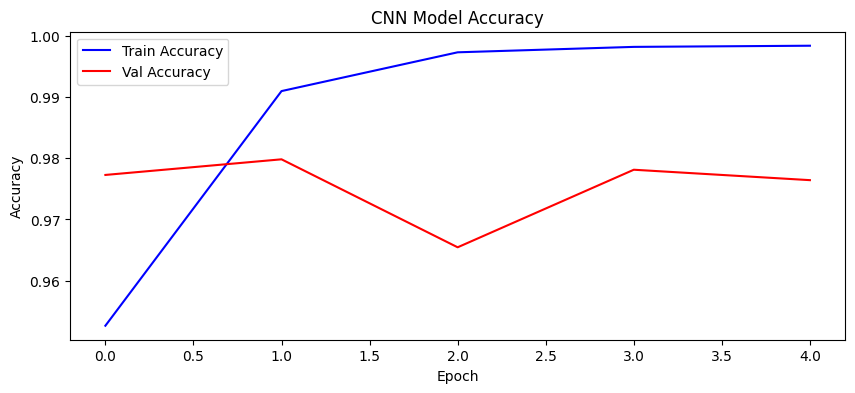


--- CNN VALIDATION RESULTS ---
Validation Accuracy: 97.98%
              precision    recall  f1-score   support

    Non-Scam     0.9820    0.9812    0.9816      5795
        Scam     0.9771    0.9782    0.9777      4765

    accuracy                         0.9798     10560
   macro avg     0.9796    0.9797    0.9796     10560
weighted avg     0.9798    0.9798    0.9798     10560



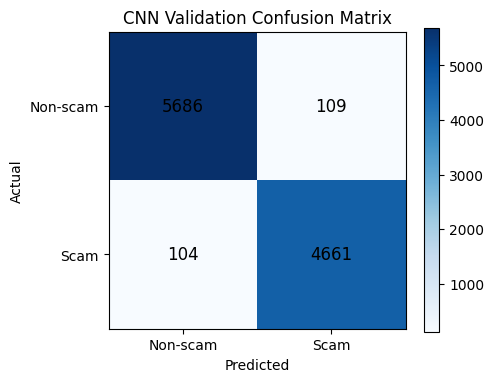


--- CNN TEST RESULTS ---
Test Accuracy: 98.05%
              precision    recall  f1-score   support

    Non-Scam     0.9824    0.9821    0.9822      5795
        Scam     0.9782    0.9786    0.9784      4766

    accuracy                         0.9805     10561
   macro avg     0.9803    0.9803    0.9803     10561
weighted avg     0.9805    0.9805    0.9805     10561



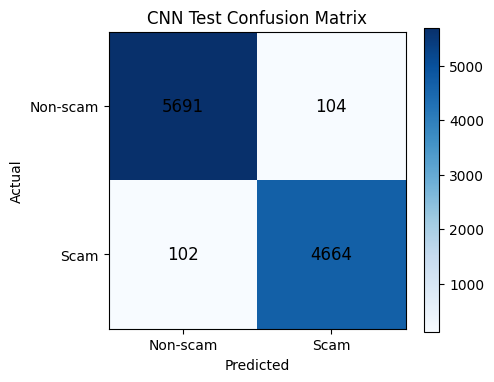

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# CNN RESULTS — Validation & Test
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import classification_report, accuracy_score

# ── Training curve ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history_cnn.history["accuracy"],     label="Train Accuracy", color="blue")
plt.plot(history_cnn.history["val_accuracy"], label="Val Accuracy",   color="red")
plt.title("CNN Model Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Epoch")
plt.legend(); plt.show()

# ── Validation set ────────────────────────────────────────────────────────────
cnn_valid_probs = best_cnn_model.predict(X_cnn_valid, verbose=0).ravel()
cnn_valid_preds = (cnn_valid_probs >= 0.5).astype(int)

print("\n--- CNN VALIDATION RESULTS ---")
print(f"Validation Accuracy: {accuracy_score(y_cnn_valid, cnn_valid_preds)*100:.2f}%")
print(classification_report(y_cnn_valid, cnn_valid_preds,
                             target_names=["Non-Scam", "Scam"], digits=4, zero_division=0))
plot_cm_like_example(y_cnn_valid, cnn_valid_preds, "CNN Validation Confusion Matrix")

# ── Test set ──────────────────────────────────────────────────────────────────
cnn_test_probs = best_cnn_model.predict(X_cnn_test, verbose=0).ravel()
cnn_test_preds = (cnn_test_probs >= 0.5).astype(int)

print("\n--- CNN TEST RESULTS ---")
print(f"Test Accuracy: {accuracy_score(y_cnn_test, cnn_test_preds)*100:.2f}%")
print(classification_report(y_cnn_test, cnn_test_preds,
                             target_names=["Non-Scam", "Scam"], digits=4, zero_division=0))
plot_cm_like_example(y_cnn_test, cnn_test_preds, "CNN Test Confusion Matrix")


## **MLP Result**

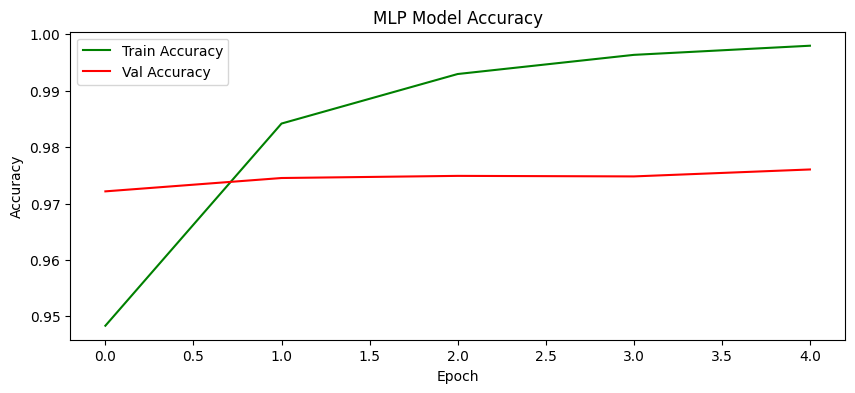


--- MLP VALIDATION RESULTS ---
Validation Accuracy: 97.45%
              precision    recall  f1-score   support

    Non-Scam     0.9762    0.9774    0.9768      5795
        Scam     0.9725    0.9710    0.9718      4765

    accuracy                         0.9745     10560
   macro avg     0.9743    0.9742    0.9743     10560
weighted avg     0.9745    0.9745    0.9745     10560



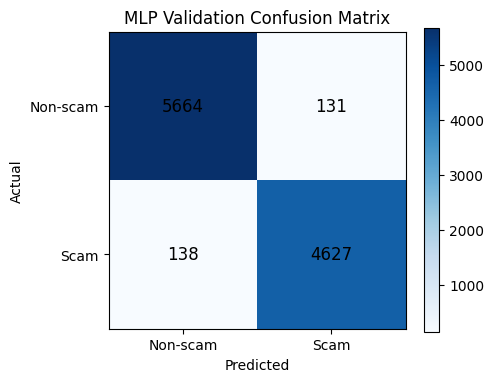


--- MLP TEST RESULTS ---
Test Accuracy: 97.68%
              precision    recall  f1-score   support

    Non-Scam     0.9786    0.9791    0.9789      5795
        Scam     0.9746    0.9740    0.9743      4766

    accuracy                         0.9768     10561
   macro avg     0.9766    0.9766    0.9766     10561
weighted avg     0.9768    0.9768    0.9768     10561



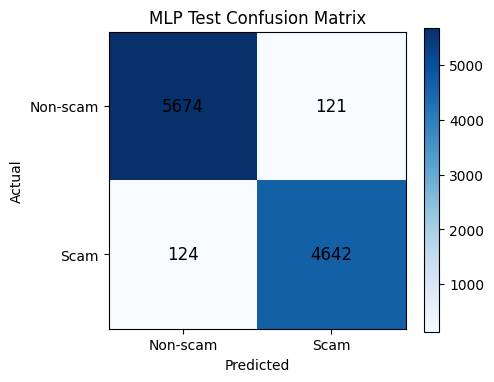

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# MLP RESULTS — Validation & Test
# ═══════════════════════════════════════════════════════════════════════════════

plt.figure(figsize=(10, 4))
plt.plot(history_mlp.history["accuracy"],     label="Train Accuracy", color="green")
plt.plot(history_mlp.history["val_accuracy"], label="Val Accuracy",   color="red")
plt.title("MLP Model Accuracy")
plt.ylabel("Accuracy"); plt.xlabel("Epoch")
plt.legend(); plt.show()

# ── Validation set ────────────────────────────────────────────────────────────
mlp_valid_probs = best_mlp_model.predict(X_mlp_valid, verbose=0).ravel()
mlp_valid_preds = (mlp_valid_probs >= 0.5).astype(int)

print("\n--- MLP VALIDATION RESULTS ---")
print(f"Validation Accuracy: {accuracy_score(y_mlp_valid, mlp_valid_preds)*100:.2f}%")
print(classification_report(y_mlp_valid, mlp_valid_preds,
                             target_names=["Non-Scam", "Scam"], digits=4, zero_division=0))
plot_cm_like_example(y_mlp_valid, mlp_valid_preds, "MLP Validation Confusion Matrix")

# ── Test set ──────────────────────────────────────────────────────────────────
mlp_test_probs = best_mlp_model.predict(X_mlp_test, verbose=0).ravel()
mlp_test_preds = (mlp_test_probs >= 0.5).astype(int)

print("\n--- MLP TEST RESULTS ---")
print(f"Test Accuracy: {accuracy_score(y_mlp_test, mlp_test_preds)*100:.2f}%")
print(classification_report(y_mlp_test, mlp_test_preds,
                             target_names=["Non-Scam", "Scam"], digits=4, zero_division=0))
plot_cm_like_example(y_mlp_test, mlp_test_preds, "MLP Test Confusion Matrix")


# More Unseen Messages Dataset Testing

| Message | Label |
|---|---|
| Your bank account has been temporarily locked. Verify your identity here immediately: [suspicious link] | Scam |
| Netflix: Your payment failed. Update billing details now to keep your account active: [suspicious link] | Scam |
| Congratulations! You won a RM5000 cash prize. Claim before midnight: [suspicious link] | Scam |
| DHL: Your parcel is on hold due to incorrect address. Confirm delivery details here: [suspicious link] | Scam |
| Your Touch n Go eWallet has been suspended. Login now to reactivate: [suspicious link] | Scam |
| LHDN: You are eligible for a tax refund. Submit your bank details here: [suspicious link] | Scam |
| Security alert: unusual login detected. Enter your OTP to secure your account now. | Scam |
| Maybank: RM1,250 transfer attempt detected. If this was not you, cancel here: [suspicious link] | Scam |
| Shopee: Your account will be deactivated due to suspicious activity. Verify now: [suspicious link] | Scam |
| Final notice: unpaid electricity bill. Pay immediately to avoid disconnection: [suspicious link] | Scam |
| Hi, are you free for lunch tomorrow? | Non-Scam |
| Your parcel has been delivered successfully. Thank you for using our service. | Non-Scam |
| Reminder: Your dentist appointment is scheduled for Friday at 10 AM. | Non-Scam |
| Mom, I reached home safely. I will call you later. | Non-Scam |
| Your meeting with the project team starts at 3 PM today. | Non-Scam |
| Thank you for your payment. Your receipt has been sent to your email. | Non-Scam |
| Hi Sarah, please send me the assignment file when you are done. | Non-Scam |
| Your food delivery rider is arriving soon. | Non-Scam |
| Class is cancelled today due to lecturer emergency. | Non-Scam |
| Can you help me buy bread and eggs on your way home? | Non-Scam |

In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# PREDICT NEW TEXT — CNN + MLP WITH MODEL CONFIDENCE
# ═══════════════════════════════════════════════════════════════════════════════

def label_confidence_from_scam_prob(scam_prob, threshold=0.5):
    label = "SCAM" if scam_prob >= threshold else "NOT SCAM"

    if label == "SCAM":
        confidence = scam_prob
    else:
        confidence = 1 - scam_prob

    return label, scam_prob, confidence


def predict_text_dl(raw_text, model, threshold=0.5):
    seq = tokenizer.texts_to_sequences([raw_text])

    padded = pad_sequences(
        seq,
        maxlen=MAX_LENGTH,
        padding=PADDING_TYPE,
        truncating=TRUNC_TYPE
    )

    scam_prob = model.predict(padded, verbose=0)[0][0]

    label, scam_prob, confidence = label_confidence_from_scam_prob(
        float(scam_prob),
        threshold
    )

    return label, scam_prob, confidence


texts = [
    ("Your bank account has been temporarily locked. Verify your identity here immediately: [suspicious link]", "Scam"),
    ("Netflix: Your payment failed. Update billing details now to keep your account active: [suspicious link]", "Scam"),
    ("Congratulations! You won a RM5000 cash prize. Claim before midnight: [suspicious link]", "Scam"),
    ("DHL: Your parcel is on hold due to incorrect address. Confirm delivery details here: [suspicious link]", "Scam"),
    ("Your Touch n Go eWallet has been suspended. Login now to reactivate: [suspicious link]", "Scam"),
    ("LHDN: You are eligible for a tax refund. Submit your bank details here: [suspicious link]", "Scam"),
    ("Security alert: unusual login detected. Enter your OTP to secure your account now.", "Scam"),
    ("Maybank: RM1,250 transfer attempt detected. If this was not you, cancel here: [suspicious link]", "Scam"),
    ("Shopee: Your account will be deactivated due to suspicious activity. Verify now: [suspicious link]", "Scam"),
    ("Final notice: unpaid electricity bill. Pay immediately to avoid disconnection: [suspicious link]", "Scam"),

    ("Hi, are you free for lunch tomorrow?", "Non-Scam"),
    ("Your parcel has been delivered successfully. Thank you for using our service.", "Non-Scam"),
    ("Reminder: Your dentist appointment is scheduled for Friday at 10 AM.", "Non-Scam"),
    ("Mom, I reached home safely. I will call you later.", "Non-Scam"),
    ("Your meeting with the project team starts at 3 PM today.", "Non-Scam"),
    ("Thank you for your payment. Your receipt has been sent to your email.", "Non-Scam"),
    ("Hi Sarah, please send me the assignment file when you are done.", "Non-Scam"),
    ("Your food delivery rider is arriving soon.", "Non-Scam"),
    ("Class is cancelled today due to lecturer emergency.", "Non-Scam"),
    ("Can you help me buy bread and eggs on your way home?", "Non-Scam"),
]


rows = []

for msg, true_label in texts:
    cnn_label, cnn_scam_prob, cnn_conf = predict_text_dl(msg, best_cnn_model)
    mlp_label, mlp_scam_prob, mlp_conf = predict_text_dl(msg, best_mlp_model)

    rows.append({
        "Message": msg,
        "True Label": true_label,

        "CNN Prediction": cnn_label,
        "CNN Scam Probability": round(cnn_scam_prob, 4),
        "CNN Model Confidence": round(cnn_conf, 4),

        "MLP Prediction": mlp_label,
        "MLP Scam Probability": round(mlp_scam_prob, 4),
        "MLP Model Confidence": round(mlp_conf, 4),
    })


results_dl_df = pd.DataFrame(rows)


def color_prediction(val):
    if val == "SCAM":
        return "background-color: #FFCCCC; color: #7B0000"
    elif val == "NOT SCAM":
        return "background-color: #CCFFCC; color: #004D00"
    return ""


display(
    results_dl_df.style
    .map(color_prediction, subset=["CNN Prediction", "MLP Prediction"])
    .format({
        "CNN Scam Probability": "{:.4f}",
        "CNN Model Confidence": "{:.4f}",
        "MLP Scam Probability": "{:.4f}",
        "MLP Model Confidence": "{:.4f}",
    })
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center"), ("vertical-align", "middle")]},
        {"selector": "td:first-child", "props": [("text-align", "left"), ("max-width", "350px"), ("white-space", "normal")]},
    ])
    .set_caption("Prediction Results — CNN vs MLP with Scam Probability and Model Confidence")
)

,Message,True Label,CNN Prediction,CNN Scam Probability,CNN Model Confidence,MLP Prediction,MLP Scam Probability,MLP Model Confidence
0,Your bank account has been temporarily locked. Verify your identity here immediately: [suspicious link],Scam,SCAM,0.9995,0.9995,SCAM,1.0000,1.0000
1,Netflix: Your payment failed. Update billing details now to keep your account active: [suspicious link],Scam,SCAM,0.9688,0.9688,SCAM,0.9999,0.9999
2,Congratulations! You won a RM5000 cash prize. Claim before midnight: [suspicious link],Scam,SCAM,0.9968,0.9968,SCAM,0.9987,0.9987
3,DHL: Your parcel is on hold due to incorrect address. Confirm delivery details here: [suspicious link],Scam,SCAM,0.9968,0.9968,SCAM,0.9998,0.9998
4,Your Touch n Go eWallet has been suspended. Login now to reactivate: [suspicious link],Scam,SCAM,0.9246,0.9246,SCAM,0.9971,0.9971
5,LHDN: You are eligible for a tax refund. Submit your bank details here: [suspicious link],Scam,SCAM,0.9589,0.9589,SCAM,0.9978,0.9978
6,Security alert: unusual login detected. Enter your OTP to secure your account now.,Scam,SCAM,0.9922,0.9922,SCAM,0.9999,0.9999
7,"Maybank: RM1,250 transfer attempt detected. If this was not you, cancel here: [suspicious link]",Scam,SCAM,0.9964,0.9964,SCAM,0.9997,0.9997
8,Shopee: Your account will be deactivated due to suspicious activity. Verify now: [suspicious link],Scam,SCAM,0.9941,0.9941,SCAM,0.9998,0.9998
9,Final notice: unpaid electricity bill. Pay immediately to avoid disconnection: [suspicious link],Scam,SCAM,0.8912,0.8912,SCAM,0.9625,0.9625


# Export FINAL model files for Scam Shield
Run the next cell after the final model training cells are complete.


In [33]:
# EXPORT DL FINAL MODELS FOR SCAM SHIELD
# Run this after best_cnn_model and best_mlp_model are trained.

from pathlib import Path
import json
import pickle

# Find the project models folder whether you launched Jupyter from project root or notebooks/.
def find_models_dir():
    candidates = [
        Path.cwd() / "models",
        Path.cwd().parent / "models",
        Path("../models").resolve(),
        Path("models").resolve(),
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    c = Path("models").resolve()
    c.mkdir(parents=True, exist_ok=True)
    return c

EXPORT_DIR = find_models_dir()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if "tokenizer" not in globals():
    raise NameError("tokenizer is missing. Run the DL_FINAL tokenization cell first.")

missing_models = [name for name in ["best_cnn_model", "best_mlp_model"] if name not in globals()]
if missing_models:
    raise NameError(
        "These trained DL models are missing. Run the DL_FINAL notebook until CNN and MLP training are complete first: "
        + ", ".join(missing_models)
    )

best_cnn_model.save(EXPORT_DIR / "dl_final_cnn.keras")
best_mlp_model.save(EXPORT_DIR / "dl_final_mlp.keras")

with open(EXPORT_DIR / "dl_final_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

config = {
    "artifact_version": "DL_FINAL",
    "preprocess": "clean_message",
    "max_length": int(globals().get("MAX_LENGTH", 100)),
    "padding_type": str(globals().get("PADDING_TYPE", "post")),
    "trunc_type": str(globals().get("TRUNC_TYPE", "post")),
    "vocab_size": int(globals().get("VOCAB_SIZE", 30000)),
    "oov_token": str(globals().get("OOV_TOKEN", "<OOV>")),
    "threshold": 0.5,
}

with open(EXPORT_DIR / "dl_final_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("DL FINAL models exported successfully to:", EXPORT_DIR)
print("Created:")
print(" -", EXPORT_DIR / "dl_final_cnn.keras")
print(" -", EXPORT_DIR / "dl_final_mlp.keras")
print(" -", EXPORT_DIR / "dl_final_tokenizer.pkl")
print(" -", EXPORT_DIR / "dl_final_config.json")


DL FINAL models exported successfully to: C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models
Created:
 - C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models\dl_final_cnn.keras
 - C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models\dl_final_mlp.keras
 - C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models\dl_final_tokenizer.pkl
 - C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models\dl_final_config.json
